# 03 — Nhánh A: phân loại xu hướng tăng/giảm

Notebook này chạy trọn quy trình của nhánh chính và **giải thích lý do đằng sau
từng lựa chọn**, thay vì chỉ gọi hàm.

Mạch nội dung:

1. Chuẩn bị dữ liệu từ bản cấu hình
2. Tách tập theo thời gian — và vì sao không được xáo trộn
3. Cho thấy hậu quả của **quá khớp** khi không ràng buộc mô hình
4. Kiểm định tiến dần (walk-forward) để đo **độ ổn định**
5. Huấn luyện mô hình cuối, đánh giá, so với **các mốc đối chứng**
6. Diễn giải mô hình qua tầm quan trọng đặc trưng
7. Dò ngưỡng quyết định trên tập validate

> Kết quả bằng số của notebook này được tổng hợp trong
> [`docs/.reports/reportResult.md`](../../docs/.reports/reportResult.md).

In [1]:
import os
import sys

# Đưa src/ vào đường dẫn tìm kiếm module để import được các package của dự án.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

import matplotlib.pyplot as plt
%matplotlib inline

from libraries import rfPlot
from libraries.randomForest import RandomForestClassifier
from pipeline import experiment, labeling, splitter
from utilities import metricsClassification

## 1. Cấu hình

In [2]:
import json

CONFIG_PATH = os.path.join(PROJECT_ROOT, 'config', 'vnm.json')
with open(CONFIG_PATH, encoding='utf-8') as handle:
    config = json.load(handle)

print(config['description'])
print(f"Dữ liệu  : {config['dataset']['path']}")
print(f"Tầm nhìn : {config['labeling']['horizon']} bước")
print(f"Đặc trưng: {sum(1 for item in config['features'] if item.get('keep', True))}")

Nhánh A — phân loại xu hướng tăng/giảm bằng Random Forest.
Dữ liệu  : data/input/VNM.csv
Tầm nhìn : 5 bước
Đặc trưng: 25


In [3]:
# Các giá trị cụ thể của lượt chạy này — sửa ở đây, không sửa trong module.
POSITIVE_LABEL = config['labeling']['positive_label']
NEGATIVE_LABEL = config['labeling']['negative_label']
SYMBOL         = config['dataset']['label']

MODEL_SETTINGS = dict(config['model'])
MODEL_SETTINGS['verbose'] = 0
MODEL_SETTINGS

{'n_estimators': 300,
 'criterion': 'gini',
 'max_depth': 5,
 'min_samples_split': 2,
 'min_samples_leaf': 40,
 'max_features': 'sqrt',
 'max_thresholds': 48,
 'bootstrap': True,
 'random_state': 42,
 'verbose': 0}

## 2. Chuẩn bị dữ liệu

`experiment.prepare_dataset()` chạy trọn mạch: nạp → làm sạch → dựng đặc trưng →
gán nhãn → cắt bỏ dòng không có nhãn.

Điểm cần nhớ: nhãn tại `t` lấy từ giá trị ở `t + horizon`, tức **dịch nhãn về sau,
không dịch đặc trưng về trước**. Làm ngược lại sẽ nhét thông tin tương lai vào
đặc trưng và cho ra kết quả tốt giả tạo.

In [4]:
dataset = experiment.prepare_dataset(config, PROJECT_ROOT)

samples       = dataset['samples']
targets       = dataset['targets']
feature_names = dataset['feature_names']
keys          = dataset['keys']

balance = labeling.calculate_class_balance(targets)
print(f"\nCân bằng lớp: {balance['counts']}")
print(f"Lớp đa số chiếm {balance['majority_ratio']:.2%} "
      f"→ đây là mốc Accuracy tối thiểu phải vượt qua.")

Đã đọc file: VNM.csv | Số dòng dữ liệu: 2587
Các cột: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Làm sạch: 2587 → 2587 dòng | gap lớn nhất 8 ngày | biến động bất thường: 0
Quan sát đứng yên: 81 (3.14%)
Đặc trưng: 27 | mẫu dùng được: 2456 (bỏ 131 dòng)

Cân bằng lớp: {0: 1316, 1: 1140}
Lớp đa số chiếm 53.58% → đây là mốc Accuracy tối thiểu phải vượt qua.


## 3. Tách tập theo thời gian

Ba tập có ba vai trò khác hẳn nhau:

| Tập | Vai trò | Điều cấm |
| --- | --- | --- |
| **Train** | Huấn luyện tham số | — |
| **Validate** | Chọn siêu tham số và ngưỡng | Không dùng để huấn luyện |
| **Test** | Ước lượng kết quả thật | Chỉ chạy **một lần duy nhất** |

Tham số `gap` chèn một khoảng trống giữa hai tập. Với `horizon = 5`, nhãn của mẫu
cuối tập train được tính từ giá trị 5 phiên sau — tức đã nằm trong vùng validate.
Không có `gap`, thông tin đó rò rỉ qua đường biên.

In [5]:
parts = experiment.split_prepared_dataset(config, dataset)

train_samples, train_targets           = parts['train']
validation_samples, validation_targets = parts['validation']
test_samples, test_targets             = parts['test']

  train       n =  1719  (70.3%)  2016-10-31 → 2023-09-06
  validation  n =   368  (15.0%)  2023-09-14 → 2025-03-12
  test        n =   359  (14.7%)  2025-03-20 → 2026-08-14


## 4. Vì sao phải ràng buộc mô hình

Rừng ngẫu nhiên để mặc định (cây mọc tự do) sẽ học thuộc nhiễu của dữ liệu tài
chính. So sánh dưới đây cho thấy khoảng cách train ↔ validate nở ra như thế nào
khi nới lỏng ràng buộc.

In [6]:
COMPARISON = [
    {'max_depth': None, 'min_samples_leaf': 1},
    {'max_depth': 12,   'min_samples_leaf': 10},
    {'max_depth': 8,    'min_samples_leaf': 20},
    {'max_depth': 5,    'min_samples_leaf': 40},
]

print(f"{'Ràng buộc':<28}{'train':>9}{'validate':>10}{'chênh lệch':>13}{'ROC-AUC':>10}")
print('-' * 70)
for override in COMPARISON:
    settings = dict(MODEL_SETTINGS)
    settings.update(override)
    settings['n_estimators'] = 100

    model = RandomForestClassifier(**settings)
    model.fit(train_samples, train_targets)

    train_accuracy = metricsClassification.calculate_accuracy(
        train_targets, model.predict(train_samples))
    validation_accuracy = metricsClassification.calculate_accuracy(
        validation_targets, model.predict(validation_samples))
    auc = metricsClassification.calculate_roc_auc(
        validation_targets, model.predict_scores(validation_samples))

    depth_text = 'không giới hạn' if override['max_depth'] is None else str(override['max_depth'])
    label = f"depth={depth_text}, leaf={override['min_samples_leaf']}"
    print(f'{label:<28}{train_accuracy:>9.4f}{validation_accuracy:>10.4f}'
          f'{train_accuracy - validation_accuracy:>13.4f}{auc:>10.4f}')

Ràng buộc                       train  validate   chênh lệch   ROC-AUC
----------------------------------------------------------------------


depth=không giới hạn, leaf=1   1.0000    0.5707       0.4293    0.6066


depth=12, leaf=10              0.9436    0.6033       0.3403    0.6354


depth=8, leaf=20               0.7807    0.6196       0.1611    0.6360


depth=5, leaf=40               0.6597    0.6250       0.0347    0.6418


Cây mọc tự do đạt Accuracy rất cao trên tập huấn luyện nhưng **không** kéo theo
kết quả tốt hơn trên validate — toàn bộ phần chênh lệch là học thuộc nhiễu.
Cấu hình được chọn (`max_depth = 5`, `min_samples_leaf = 40`) giữ khoảng cách
này ở mức nhỏ.

## 5. Kiểm định tiến dần

Một con số Accuracy trên validate chưa đủ. Cần biết mô hình có **ổn định** khi
điều kiện thị trường đổi hay không — đó là việc của kiểm định tiến dần.

  vòng 1: train =  1043  validate =  207  điểm = 0.5797


  vòng 2: train =  1250  validate =  207  điểm = 0.6039


  vòng 3: train =  1457  validate =  207  điểm = 0.5749


  vòng 4: train =  1664  validate =  207  điểm = 0.5942


  vòng 5: train =  1871  validate =  211  điểm = 0.5545

Trung bình = 0.5814 ± 0.0170


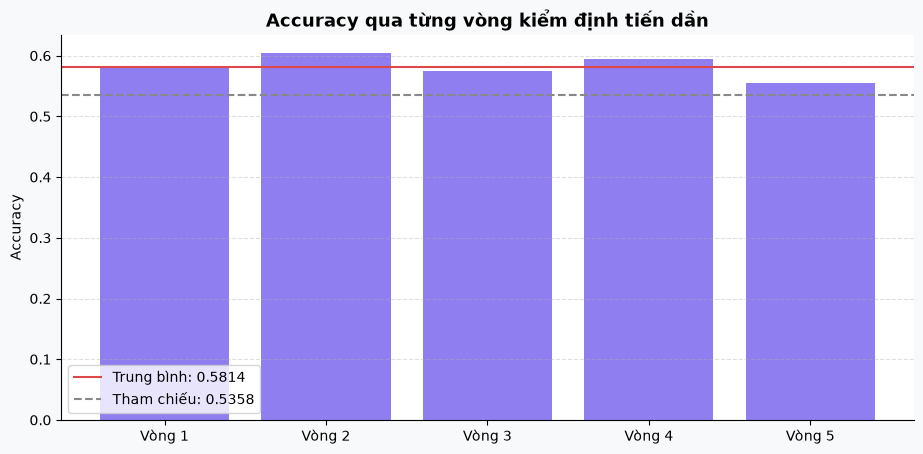

In [7]:
walk_forward = experiment.run_walk_forward(
    config,
    train_samples + validation_samples,
    train_targets + validation_targets,
    model_factory=lambda: RandomForestClassifier(**MODEL_SETTINGS),
    score_function=metricsClassification.calculate_accuracy,
)

print(f"\nTrung bình = {walk_forward['mean']:.4f} "
      f"± {walk_forward['standard_deviation']:.4f}")

rfPlot.plot_fold_scores(
    [f'Vòng {position}' for position in range(1, len(walk_forward['fold_scores']) + 1)],
    walk_forward['fold_scores'],
    reference_value=balance['majority_ratio'],
    title='Accuracy qua từng vòng kiểm định tiến dần',
    y_label='Accuracy',
)
plt.show()

## 6. Huấn luyện mô hình cuối

In [8]:
model = RandomForestClassifier(**MODEL_SETTINGS)
model.fit(train_samples, train_targets)

structure = model.describe()
for name, value in structure.items():
    print(f'  {name:<26}: '
          f'{value:.4f}' if isinstance(value, float) else f'  {name:<26}: {value}')

  num_trees                 : 300
  num_features              : 27
  max_features_resolved     : 5
  average_depth             : 5.0000
  average_leaves            : 13.5133
  average_nodes             : 26.0267
  average_out_of_bag_ratio  : 0.3676


### 6.1. Kiểm chứng lý thuyết bootstrap

Tỷ lệ mẫu ngoài túi thực tế phải tiến về `1/e ≈ 0.3679`. Đây là phép kiểm tra
nhanh cho thấy cài đặt bootstrap chạy đúng.

In [9]:
from libraries import rfMath

print(f"Tỷ lệ OOB thực tế   : {structure['average_out_of_bag_ratio']:.4f}")
print(f"Tỷ lệ OOB lý thuyết : "
      f"{rfMath.calculate_expected_out_of_bag_ratio(len(train_samples)):.4f}")
print(f"Giới hạn 1/e        : {1 / 2.718281828459045:.4f}")

Tỷ lệ OOB thực tế   : 0.3676
Tỷ lệ OOB lý thuyết : 0.3678
Giới hạn 1/e        : 0.3679


### 6.2. Chọn số cây bằng đường cong OOB

Lỗi ngoài túi cho ta một ước lượng **miễn phí** mà không tốn dữ liệu validate.
Điểm đường cong đi ngang là ngưỡng bão hoà — thêm cây nữa chỉ tốn thời gian.

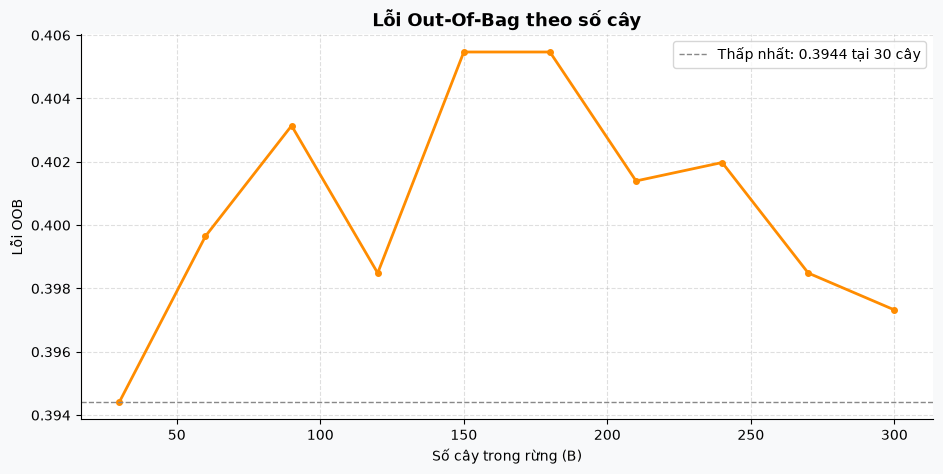

Lỗi OOB của mô hình cuối: 0.3973


In [10]:
tree_counts, oob_errors = model.calculate_out_of_bag_error_curve()

rfPlot.plot_out_of_bag_curve(tree_counts, oob_errors)
plt.show()

print(f'Lỗi OOB của mô hình cuối: {model.calculate_out_of_bag_error():.4f}')

## 7. Đánh giá trên ba tập

In [11]:
evaluations = {}
for name, (split_samples, split_targets) in (('train', parts['train']),
                                             ('validation', parts['validation']),
                                             ('test', parts['test'])):
    predictions = model.predict(split_samples)
    scores = model.predict_scores(split_samples, positive_label=POSITIVE_LABEL)
    results = metricsClassification.calculate_all_classification_metrics(
        split_targets, predictions, scores, positive_label=POSITIVE_LABEL)
    results['report'] = metricsClassification.build_classification_report(
        split_targets, predictions)
    results['scores'] = scores
    evaluations[name] = results

header = (f"{'Tập':<12}{'Accuracy':>10}{'ROC-AUC':>10}{'F1(+)':>9}"
          f"{'F1(-)':>9}{'BalAcc':>9}{'MCC':>9}{'LogLoss':>10}")
print(header)
print('-' * len(header))
for name in ('train', 'validation', 'test'):
    results = evaluations[name]
    per_class = results['report']['per_class']
    print(f"{name:<12}{results['accuracy']:>10.4f}{results['roc_auc']:>10.4f}"
          f"{per_class[POSITIVE_LABEL]['f1_score']:>9.4f}"
          f"{per_class[NEGATIVE_LABEL]['f1_score']:>9.4f}"
          f"{results['balanced_accuracy']:>9.4f}"
          f"{results['matthews_correlation']:>+9.4f}"
          f"{results['log_loss']:>10.4f}")

Tập           Accuracy   ROC-AUC    F1(+)    F1(-)   BalAcc      MCC   LogLoss
------------------------------------------------------------------------------
train           0.6597    0.7663   0.5524   0.7255   0.6480  +0.3260    0.6337
validation      0.6087    0.6476   0.4098   0.7073   0.5697  +0.1608    0.6613
test            0.5237    0.5313   0.4706   0.5671   0.5215  +0.0436    0.6914


In [12]:
print('Báo cáo chi tiết — tập validate:\n')
print(metricsClassification.format_classification_report(
    evaluations['validation']['report']))

Báo cáo chi tiết — tập validate:

Lớp            Precision      Recall    F1-score   Support
----------------------------------------------------------
0                 0.6237      0.8169      0.7073       213
1                 0.5618      0.3226      0.4098       155
----------------------------------------------------------
Macro avg         0.5927      0.5697      0.5586          
Weighted avg      0.5976      0.6087      0.5820          
Accuracy          0.6087


## 8. So với các mốc đối chứng

Đây là phần dễ bị bỏ qua nhất và cũng quan trọng nhất. Với dữ liệu tài chính, một
Accuracy 60% nghe có vẻ tốt nhưng vô nghĩa nếu mốc đoán bừa cũng đạt 60%.

In [13]:
majority_label = balance['majority_label']
lag_position = feature_names.index('return_lag_1')

for split_name, (split_samples, split_targets) in (
        ('validate', parts['validation']), ('test', parts['test'])):
    baselines = {
        'majority': metricsClassification.calculate_accuracy(
            split_targets, [majority_label] * len(split_targets)),
        'persistence': metricsClassification.calculate_accuracy(
            split_targets,
            [POSITIVE_LABEL if sample[lag_position] > 0 else NEGATIVE_LABEL
             for sample in split_samples]),
        'alternating': metricsClassification.calculate_accuracy(
            split_targets,
            [POSITIVE_LABEL if index % 2 else NEGATIVE_LABEL
             for index in range(len(split_targets))]),
    }
    key = 'validation' if split_name == 'validate' else 'test'
    model_accuracy = evaluations[key]['accuracy']

    print(f'\n[{split_name}]  mô hình = {model_accuracy:.4f}')
    for name, value in sorted(baselines.items()):
        marker = '✓' if model_accuracy > value else '✗'
        print(f'    {marker} {name:<14}{value:.4f}   '
              f'(chênh lệch {model_accuracy - value:+.4f})')


[validate]  mô hình = 0.6087
    ✓ alternating   0.5136   (chênh lệch +0.0951)
    ✓ majority      0.5788   (chênh lệch +0.0299)
    ✓ persistence   0.5326   (chênh lệch +0.0761)

[test]  mô hình = 0.5237
    ✓ alternating   0.4708   (chênh lệch +0.0529)
    ✓ majority      0.5125   (chênh lệch +0.0111)
    ✓ persistence   0.4708   (chênh lệch +0.0529)


## 9. Ma trận nhầm lẫn và đường ROC

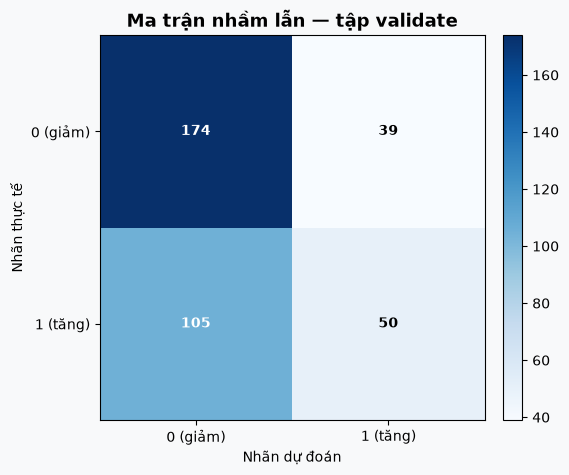

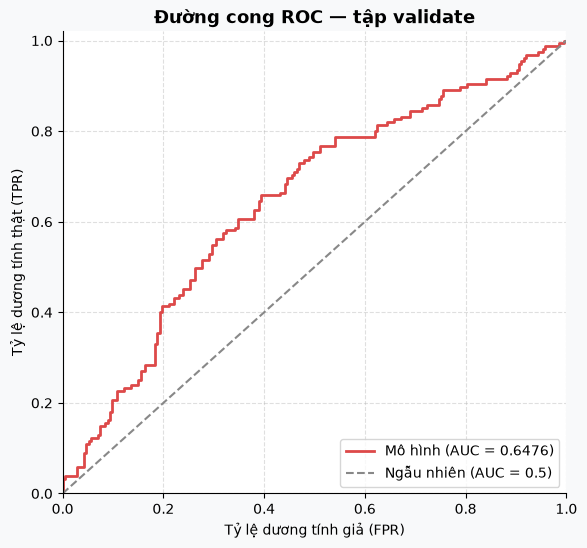

In [14]:
rfPlot.plot_confusion_matrix(
    evaluations['validation']['confusion_matrix'],
    [f'{label} ({"tăng" if label == POSITIVE_LABEL else "giảm"})'
     for label in evaluations['validation']['label_space']],
    title='Ma trận nhầm lẫn — tập validate',
)
plt.show()

false_positive_rates, true_positive_rates, _ = \
    metricsClassification.calculate_roc_curve(
        validation_targets, evaluations['validation']['scores'],
        positive_label=POSITIVE_LABEL)

rfPlot.plot_roc_curve(
    false_positive_rates, true_positive_rates,
    evaluations['validation']['roc_auc'],
    title='Đường cong ROC — tập validate',
)
plt.show()

## 10. Mô hình đã dựa vào đâu

Hai cách đo tầm quan trọng đặt cạnh nhau. MDI thiên vị đặc trưng có nhiều giá trị
phân biệt; permutation importance đo trực tiếp mức tăng lỗi khi xáo trộn một đặc
trưng trên **tập validate**, nên đáng tin hơn khi cần kết luận.

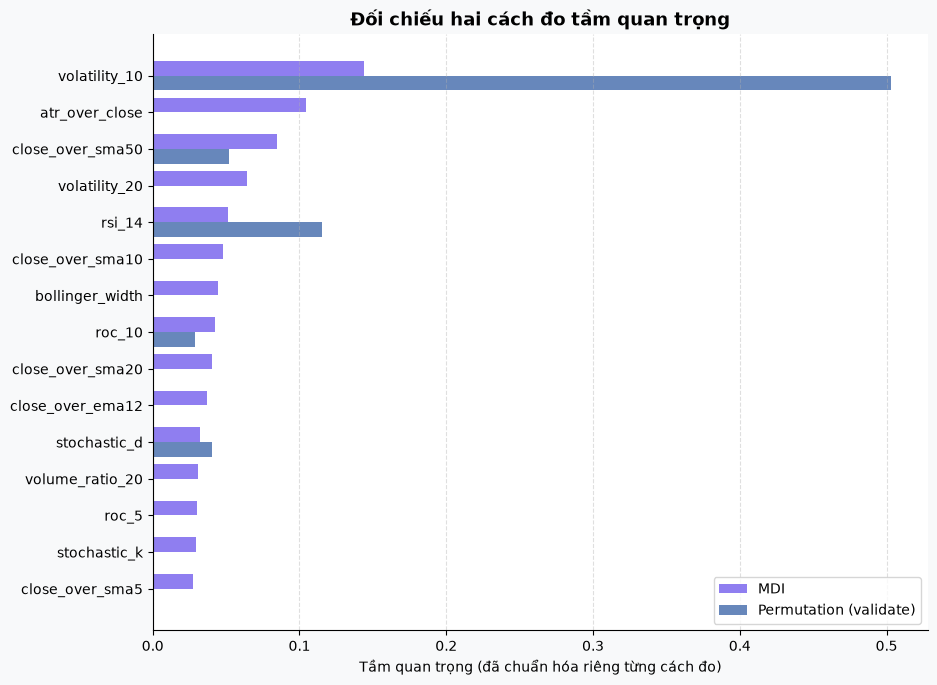

In [15]:
impurity_importances = model.calculate_feature_importances()
permutation_importances = model.calculate_permutation_importances(
    validation_samples, validation_targets,
    num_repeats=config['evaluation']['permutation_repeats'],
    random_state=MODEL_SETTINGS['random_state'],
)

total = sum(max(value, 0.0) for value in permutation_importances)
normalized = [max(value, 0.0) / total if total else 0.0
              for value in permutation_importances]

rfPlot.plot_importance_comparison(
    feature_names, impurity_importances, normalized,
    first_label='MDI', second_label='Permutation (validate)',
    top_k=config['evaluation']['top_features'],
)
plt.show()

In [16]:
ranked = sorted(zip(feature_names, impurity_importances, permutation_importances),
                key=lambda item: item[1], reverse=True)

print(f"{'Đặc trưng':<20}{'MDI':>10}{'Permutation':>14}")
print('-' * 44)
for name, impurity, permutation in ranked[:10]:
    print(f'{name:<20}{impurity:>10.4f}{permutation:>+14.5f}')

Đặc trưng                  MDI   Permutation
--------------------------------------------
volatility_10           0.1442      +0.04728
atr_over_close          0.1044      -0.00326
close_over_sma50        0.0850      +0.00489
volatility_20           0.0645      -0.00543
rsi_14                  0.0515      +0.01087
close_over_sma10        0.0482      -0.00380
bollinger_width         0.0448      -0.00000
roc_10                  0.0422      +0.00272
close_over_sma20        0.0405      -0.00000
close_over_ema12        0.0368      -0.00109


## 11. Ngưỡng quyết định

Ngưỡng mặc định 0.5 hiếm khi là lựa chọn tốt nhất. Việc dò ngưỡng **chỉ được làm
trên tập validate**, sau đó áp nguyên vẹn cho tập test — dò trên chính tập test
sẽ cho kết quả tốt giả tạo.

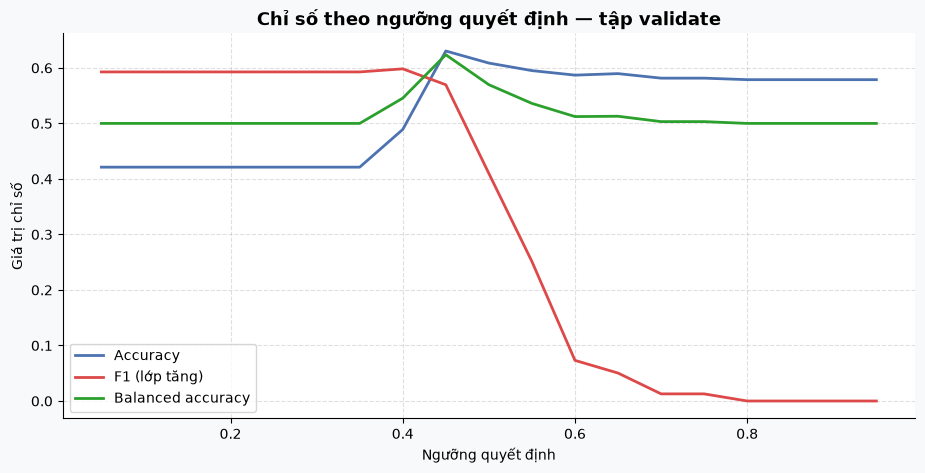

Ngưỡng tốt nhất theo balanced accuracy: 0.45 (validate = 0.6237)


In [17]:
thresholds, accuracy_values = metricsClassification.scan_thresholds(
    validation_targets, evaluations['validation']['scores'],
    metricsClassification.calculate_accuracy, positive_label=POSITIVE_LABEL)
_, f1_values = metricsClassification.scan_thresholds(
    validation_targets, evaluations['validation']['scores'],
    metricsClassification.calculate_f1_score, positive_label=POSITIVE_LABEL)
_, balanced_values = metricsClassification.scan_thresholds(
    validation_targets, evaluations['validation']['scores'],
    metricsClassification.calculate_balanced_accuracy, positive_label=POSITIVE_LABEL)

rfPlot.plot_threshold_curve(
    thresholds,
    {'Accuracy': accuracy_values, 'F1 (lớp tăng)': f1_values,
     'Balanced accuracy': balanced_values},
    title='Chỉ số theo ngưỡng quyết định — tập validate',
)
plt.show()

best_threshold, best_score = metricsClassification.find_best_threshold(
    validation_targets, evaluations['validation']['scores'],
    metricsClassification.calculate_balanced_accuracy,
    positive_label=POSITIVE_LABEL)
print(f'Ngưỡng tốt nhất theo balanced accuracy: {best_threshold:.2f} '
      f'(validate = {best_score:.4f})')

In [18]:
tuned_predictions = metricsClassification.apply_threshold(
    evaluations['test']['scores'], best_threshold, POSITIVE_LABEL, NEGATIVE_LABEL)

print('Trên tập TEST:')
print(f"  ngưỡng 0.50            : accuracy = {evaluations['test']['accuracy']:.4f}  "
      f"balanced = {evaluations['test']['balanced_accuracy']:.4f}")
print(f'  ngưỡng {best_threshold:.2f} (từ validate): accuracy = '
      f'{metricsClassification.calculate_accuracy(test_targets, tuned_predictions):.4f}  '
      f'balanced = '
      f'{metricsClassification.calculate_balanced_accuracy(test_targets, tuned_predictions):.4f}')

Trên tập TEST:
  ngưỡng 0.50            : accuracy = 0.5237  balanced = 0.5215
  ngưỡng 0.45 (từ validate): accuracy = 0.5153  balanced = 0.5175


## 12. Đọc kết quả một cách trung thực

Thị trường tài chính có tỷ lệ nhiễu trên tín hiệu rất cao. Cần đối chiếu kết quả
với sáu tiêu chí chấp nhận trong README §8.4 và **ghi nhận cả những tiêu chí
không đạt** — đó mới là báo cáo có giá trị.

Nếu một mô hình cho Accuracy vượt 70%, khả năng cao nhất không phải là mô hình
giỏi mà là **có rò rỉ dữ liệu**. Khi đó cần rà lại bốn nguyên tắc ở README §5.2
trước khi báo cáo bất cứ điều gì.

Bước tiếp theo: [`04_train_regress.ipynb`](04_train_regress.ipynb).